In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
import Plots as plt
using LaTeXStrings

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`


In [2]:
# defining the Fuller constant
const ξ = sqrt((sqrt(33) - 1) / 24)

0.44462356018593735

In [3]:
# Define the vector fields
# F is active when H(x) > 0 (Region G_ -> u = -1)
function F(x)
    return [x[2], -1.0]
end

F (generic function with 1 method)

In [4]:
# G is active when H(x) < 0 (Region G_+ -> u = +1)
function G(x)
    return [x[2], 1.0]
end

G (generic function with 1 method)

In [5]:
# Defining the guard
function H(x)
    return x[1] + sign(x[2]) * ξ * x[2]^2
end

H (generic function with 1 method)

In [6]:
# Define the Normal
function N(x)
    return [1.0, 2.0 * ξ * abs(x[2])]
end

N (generic function with 1 method)

In [34]:
# Setting up two trajectories to plot later!
x0_1 = [0.15, 0.35]
prob1 = HD.prob(sys, x0_1, (0.0, 5.0))
sol1 = HD.solve(prob1, HD.RK45())

x0_2 = [-0.15, -0.35] 
prob2 = HD.prob(sys, x0_2, (0.0, 5.0))
sol2 = HD.solve(prob2, HD.RK45())


HybridDynamics.FilippovSol{Vector{Float64}, Vector{Vector{Float64}}, Vector{Vector{Float64}}, Vector{Float64}, Vector{Float64}, Vector{Int64}}([0.0, 0.0012914234194302881, 0.002496703682742181, 0.0036530813007906544, 0.004781074955326592, 0.005892373752189224, 0.006993774473915849, 0.008089278717672666, 0.00918126023787865, 0.01027113356359973  …  4.990604851320118, 4.991691569983121, 4.992778288646123, 4.993865007309126, 4.994951725972129, 4.996038444635132, 4.997125163298135, 4.998211881961137, 4.99929860062414, 5.0], [[-0.15, -0.35], [-0.15045033042235234, -0.3487085765805697], [-0.15086916928683936, -0.3475032963172578], [-0.15126967711170317, -0.3463469186992093], [-0.15165908186857927, -0.3452189250446734], [-0.15204148825961972, -0.34410762624781077], [-0.15241927556397086, -0.3430062255260842], [-0.1527938402101216, -0.34191072128232736], [-0.15316600797568172, -0.34081873976212135], [-0.15353626940518822, -0.33972886643640027]  …  [-0.00010020439446271056, -0.00096421261151076

In [35]:
# Extracting states for both trajectories. 
x1 = [state[1] for state in sol1.x]
y1 = [state[2] for state in sol1.x]

x2 = [state[1] for state in sol2.x]
y2 = [state[2] for state in sol2.x];

In [36]:
# Generating the switchig manifold (guard) over what the plot will show
y_surf = range(-0.5, 0.5, length=200)
x_surf = [-sign(y) * ξ * y^2 for y in y_surf];


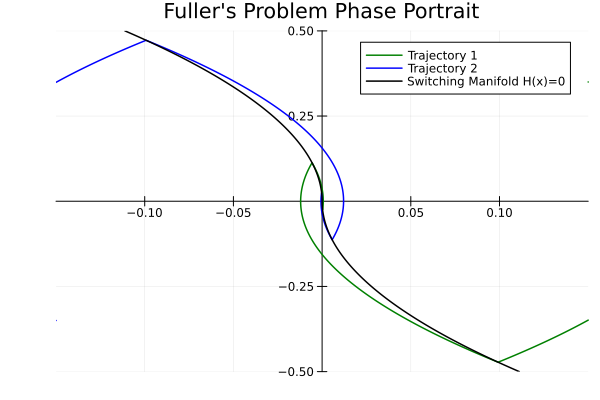

In [37]:
# Making the plot. 
plt.plot(x1, y1, 
    title="Fuller's Problem Phase Portrait", 
    label="Trajectory 1", 
    lw=1.5, color=:green,
    framestyle=:origin,      # Forces the x and y axes to cross at (0,0)
    xlims=(-0.15, 0.15),     # Narrows the X bounds to stretch the curves horizontally (so we can see what happens)
    ylims=(-0.5, 0.5),       # Keeps the Y bounds tall
    grid=true,
    legend=:topright
)
plt.plot!(x2, y2, label="Trajectory 2", lw=1.5, color=:blue)
plt.plot!(x_surf, y_surf, label="Switching Manifold H(x)=0", color=:black, lw=1.5)